# Задание 1

Сравниваются ReLU, tanh, identity и LeakyReLU (дополнительная часть).
Инициализации: константа 0.01, нормальное распределение со стандартным отклонением 0.01, Xavier и Kaiming. Смещения равны нулю.


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import FashionMNIST
import matplotlib.pyplot as plt

torch.manual_seed(42);


In [2]:
FashionMNIST.mirrors = ["https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"]
train_data = FashionMNIST("data", train=True, download=True)
test_data = FashionMNIST("data", train=False, download=True)

x_train = train_data.data.float().unsqueeze(1) / 255
x_test = test_data.data.float().unsqueeze(1) / 255
mean, std = x_train.mean(), x_train.std()
x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

train_loader = DataLoader(TensorDataset(x_train, train_data.targets), batch_size=256, shuffle=True)
test_loader = DataLoader(TensorDataset(x_test, test_data.targets), batch_size=256)


In [3]:
class BaseNetwork(nn.Module):
    def __init__(self, act_fn, input_size=784, num_classes=10, hidden_sizes=[512, 256, 256, 128]):
        super().__init__()
        layers = []
        sizes = [input_size] + hidden_sizes
        for i in range(1, len(sizes)):
            layers += [nn.Linear(sizes[i - 1], sizes[i]), act_fn]
        layers += [nn.Linear(sizes[-1], num_classes)]
        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        for layer in self.layers:
            x = layer(x)
        return x


In [4]:
activations = {
    "ReLU": nn.ReLU,
    "tanh": nn.Tanh,
    "identity": nn.Identity,
    "LeakyReLU": lambda: nn.LeakyReLU(0.1)
}
initializations = ["constant", "normal", "xavier", "kaiming"]
nonlinearities = {"ReLU": "relu", "tanh": "tanh", "identity": "linear", "LeakyReLU": "leaky_relu"}


def make_model(activation, initialization):
    torch.manual_seed(42)
    model = BaseNetwork(activations[activation]())
    for i, layer in enumerate(model.layers):
        if isinstance(layer, nn.Linear):
            nonlinearity = nonlinearities[activation] if i < len(model.layers) - 1 else "linear"
            gain = nn.init.calculate_gain(nonlinearity, 0.1)
            if initialization == "constant":
                nn.init.constant_(layer.weight, 0.01)
            elif initialization == "normal":
                nn.init.normal_(layer.weight, std=0.01)
            elif initialization == "xavier":
                nn.init.xavier_normal_(layer.weight, gain=gain)
            else:
                nn.init.kaiming_normal_(layer.weight, a=0.1, nonlinearity=nonlinearity)
            nn.init.zeros_(layer.bias)
    return model


## Активации и градиенты до обучения

Для одного и того же батча из 256 обучающих изображений считается CrossEntropyLoss и выполняется backward.
На графиках показан RMS выходов и их градиентов для каждого Linear и каждой функции активации: L — Linear, A — активация.
К RMS добавляется $10^{-12}$ только для отображения нулей на логарифмической шкале.
В Xavier и Kaiming учитывается функция активации; для последнего линейного слоя используется gain = 1.


In [5]:
def layer_statistics(model, x, y):
    outputs = []
    x = x.flatten(1)
    for layer in model.layers:
        x = layer(x)
        x.retain_grad()
        outputs.append(x)
    nn.CrossEntropyLoss()(x, y).backward()
    activation_rms = [out.detach().square().mean().sqrt().item() for out in outputs]
    gradient_rms = [out.grad.square().mean().sqrt().item() for out in outputs]
    return activation_rms, gradient_rms


statistics = {}
for activation in activations:
    for initialization in initializations:
        model = make_model(activation, initialization)
        statistics[activation, initialization] = layer_statistics(model, x_train[:256], train_data.targets[:256])


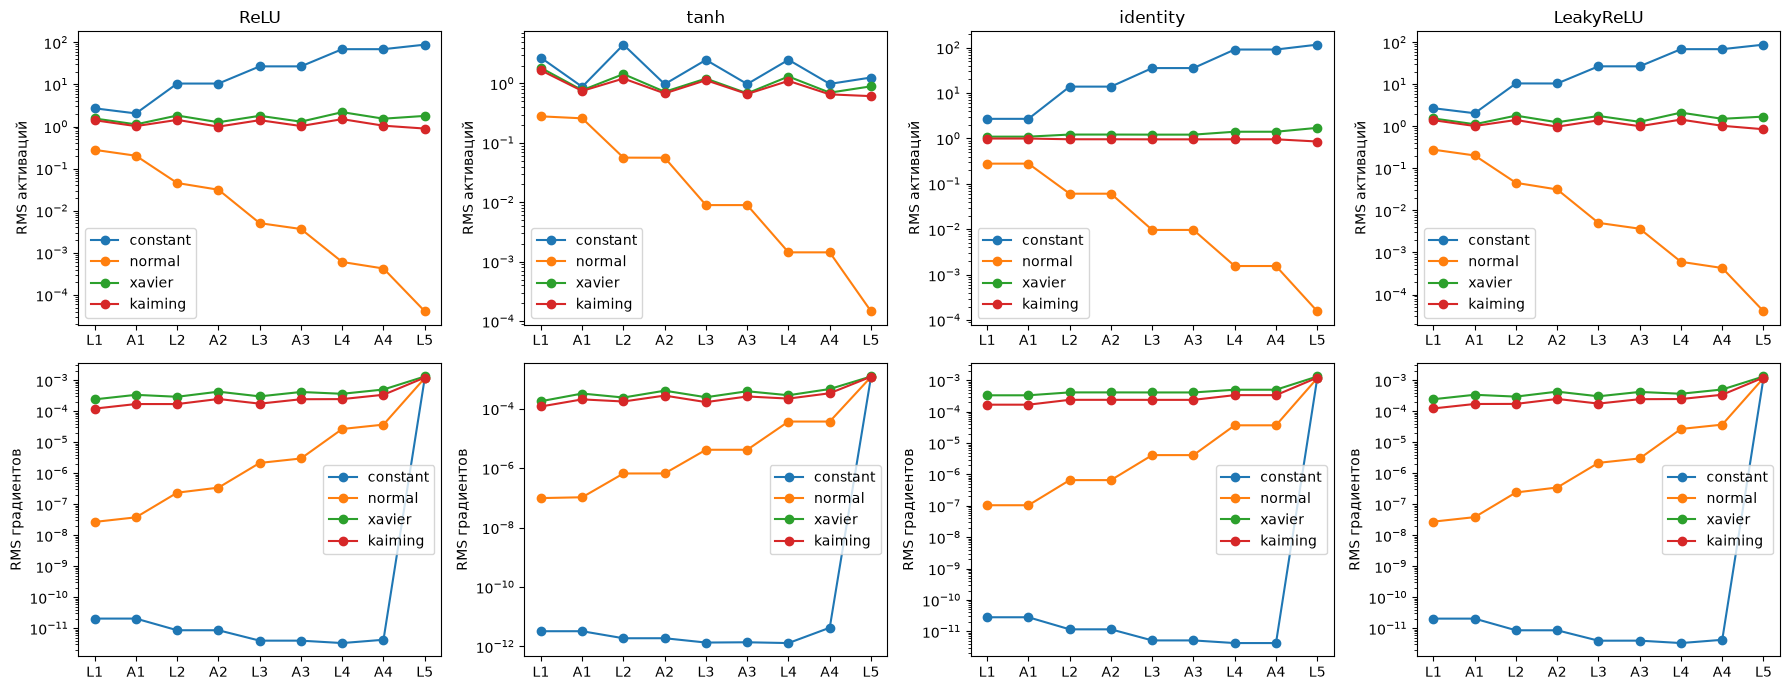

In [6]:
layer_names = ["L1", "A1", "L2", "A2", "L3", "A3", "L4", "A4", "L5"]
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for column, activation in enumerate(activations):
    for initialization in initializations:
        activation_rms, gradient_rms = statistics[activation, initialization]
        axes[0, column].plot(layer_names, [v + 1e-12 for v in activation_rms], marker="o", label=initialization)
        axes[1, column].plot(layer_names, [v + 1e-12 for v in gradient_rms], marker="o", label=initialization)
    axes[0, column].set_title(activation)
    for row, ylabel in enumerate(["RMS активаций", "RMS градиентов"]):
        axes[row, column].set_yscale("log")
        axes[row, column].set_ylabel(ylabel)
        axes[row, column].legend()
plt.tight_layout()
plt.show()


## Обучение на FashionMNIST

Используются все 60 000 обучающих и 10 000 тестовых изображений. Нормализация вычисляется только по обучающим данным.
Для всех 16 сочетаний одинаковы архитектура, порядок батчей, batch size = 256, SGD без momentum, learning rate = 0.01 и 8 эпох.
Тестовая выборка используется только для оценки. Loss на обучении усредняется по всем изображениям во время эпохи.


In [7]:
def train_model(model, epochs=8):
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "test_loss": [], "test_accuracy": []}

    for _ in range(epochs):
        model.train()
        train_loss = 0
        for x, y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(y)

        model.eval()
        test_loss = 0
        correct = 0
        with torch.no_grad():
            for x, y in test_loader:
                logits = model(x)
                test_loss += criterion(logits, y).item() * len(y)
                correct += (logits.argmax(dim=1) == y).sum().item()

        history["train_loss"].append(train_loss / len(train_loader.dataset))
        history["test_loss"].append(test_loss / len(test_loader.dataset))
        accuracy = correct / len(test_loader.dataset)
        if not torch.isfinite(torch.tensor(test_loss)):
            accuracy = float("nan")
        history["test_accuracy"].append(accuracy)
    return history


In [8]:
histories = {}
for activation in activations:
    for initialization in initializations:
        model = make_model(activation, initialization)
        torch.manual_seed(123)
        history = train_model(model)
        histories[activation, initialization] = history
        print(f"{activation:10} {initialization:8} loss={history['test_loss'][-1]:.4f} accuracy={history['test_accuracy'][-1]:.4f}")


ReLU       constant loss=2.3026 accuracy=0.1000


ReLU       normal   loss=2.3025 accuracy=0.1000


ReLU       xavier   loss=0.3993 accuracy=0.8556


ReLU       kaiming  loss=0.4004 accuracy=0.8547


tanh       constant loss=2.0894 accuracy=0.1835


...

identity   kaiming  loss=0.4729 accuracy=0.8321


LeakyReLU  constant loss=2.3026 accuracy=0.0999


LeakyReLU  normal   loss=2.3025 accuracy=0.1000


LeakyReLU  xavier   loss=0.3994 accuracy=0.8547


LeakyReLU  kaiming  loss=0.4030 accuracy=0.8523


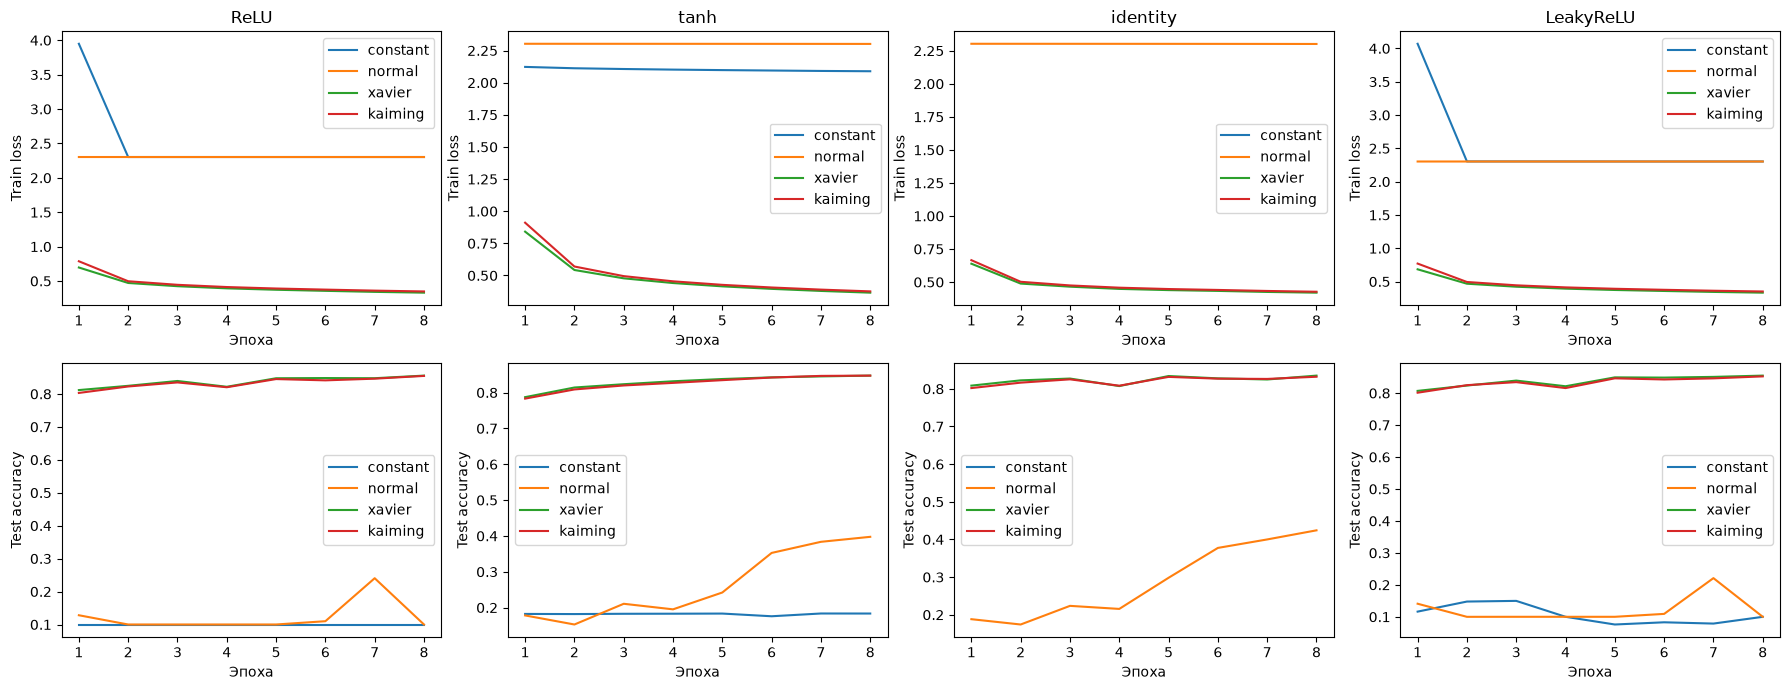

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for column, activation in enumerate(activations):
    for initialization in initializations:
        history = histories[activation, initialization]
        axes[0, column].plot(range(1, 9), history["train_loss"], label=initialization)
        axes[1, column].plot(range(1, 9), history["test_accuracy"], label=initialization)
    axes[0, column].set_title(activation)
    for row, ylabel in enumerate(["Train loss", "Test accuracy"]):
        axes[row, column].set_xlabel("Эпоха")
        axes[row, column].set_ylabel(ylabel)
        axes[row, column].legend()
plt.tight_layout()
plt.show()


## Выводы

Константная инициализация не нарушает симметрию нейронов. До обучения градиенты скрытых слоёв практически равны нулю. Для identity обучение расходится: loss становится NaN, поэтому accuracy не определяется.

При normal со std = 0.01 активации затухают по глубине, а градиенты — при распространении к первым слоям. ReLU и LeakyReLU остаются около 10% accuracy. tanh и identity достигают 39.75% и 42.42%, но loss остаётся около 2.30: предсказания почти равномерны, обучение идёт медленно.

Для ReLU и LeakyReLU Kaiming сохраняет RMS скрытых активаций около 1. Xavier с учётом gain тоже стабилен. После 8 эпох ReLU достигает 85.56% с Xavier и 85.47% с Kaiming; LeakyReLU — 85.47% и 85.23%.

Для tanh стабильны Xavier и Kaiming с gain = 5/3: активации не затухают по глубине, градиенты сохраняют сопоставимый масштаб. Обе модели получают 84.73% accuracy.

Для identity стабильны Xavier и Kaiming с gain = 1: accuracy составляет 83.51% и 83.21%. Без нелинейности вся сеть эквивалентна одному линейному преобразованию и уступает ReLU в этом эксперименте.

Для ReLU и LeakyReLU подходит Kaiming, для tanh — Xavier с gain = 5/3, для identity — Xavier или Kaiming с gain = 1. Разница между Xavier и Kaiming здесь мала; один seed и 8 эпох не доказывают универсального преимущества одной инициализации.

Источники: [FashionMNIST](https://github.com/zalandoresearch/fashion-mnist), [инициализации PyTorch](https://docs.pytorch.org/docs/stable/nn.init.html).
